In [10]:
import pandas as pd 
import datamol as dm
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

slurm_job_id = 155490

smiles_col = 'smiles'
run_path = Path(f'/compchem/arc/users/dvik/repos/SyntheMol/runs/delqsar_real_rl_{slurm_job_id}')


In [13]:
mol_df = pd.read_csv(run_path / "molecules.csv")

# concat the building block ids to get a unique identifier for each building block combination start with reaction_1_id, then building_block_1_1_id, then building_block_1_2_id, then building_block_1_3_id if it exists, if not just use the first two ids
mol_df['real_id'] = mol_df['reaction_1_id'].astype(str) + '__' + mol_df['building_block_1_1_id'].astype(str) + '__' + mol_df['building_block_1_2_id'].astype(str) + '__' + mol_df['building_block_1_3_id'].fillna('').astype(str)
# strip the trailing __ if building_block_1_3_id is missing
mol_df['real_id'] = mol_df['real_id'].str.rstrip('__')

mol_df


,smiles,node_id,num_expansions,rollout_num,score,Score 1,Q_value,num_reactions,reaction_1_chemical_space,reaction_1_id,building_block_1_1_id,building_block_1_1_smiles,building_block_1_2_id,building_block_1_2_smiles,building_block_1_3_id,building_block_1_3_smiles,real_id
0,CC(C)(C)C1=N/C(=C\C23C4=C5C6=C2[Fe]56432789C3=...,116780,80,21,1851.556274,1851.556274,1851.556274,1,real,10,31766,CC(C)(C)C(=O)NCC(=O)O,47410,O=CC12C3=C4C5=C1[Fe]45321678C2=C1C6C7=C28,NaN,NaN,10__31766__47410
1,O=C1OC(c2cccs2)=N/C1=C\C12C3=C4C5=C1[Fe]453216...,116763,1,13,1772.622925,1772.622925,1772.622925,1,real,10,5667,O=C(O)CNC(=O)c1cccs1,47410,O=CC12C3=C4C5=C1[Fe]45321678C2=C1C6C7=C28,NaN,NaN,10__5667__47410
2,Cc1occc1C1=N/C(=C\C23C4=C5C6=C2[Fe]56432789C3=...,116765,1,14,1699.109619,1699.109619,1699.109619,1,real,10,89084,Cc1occc1C(=O)NCC(=O)O,47410,O=CC12C3=C4C5=C1[Fe]45321678C2=C1C6C7=C28,NaN,NaN,10__89084__47410
3,Cc1ccccc1C1=N/C(=C\C23C4=C5C6=C2[Fe]56432789C3...,116761,1,12,1631.638672,1631.638672,1631.638672,1,real,10,11368,Cc1ccccc1C(=O)NCC(=O)O,47410,O=CC12C3=C4C5=C1[Fe]45321678C2=C1C6C7=C28,NaN,NaN,10__11368__47410
4,O=C1OC(c2ccc(F)cc2F)=N/C1=C\C12C3=C4C5=C1[Fe]4...,116769,1,16,1571.151001,1571.151001,1571.151001,1,real,10,32592,O=C(O)CNC(=O)c1ccc(F)cc1F,47410,O=CC12C3=C4C5=C1[Fe]45321678C2=C1C6C7=C28,NaN,NaN,10__32592__47410
5,COc1ccc(C2=N/C(=C\C34C5=C6C7=C3[Fe]6754389%10C...,116759,1,11,1567.175659,1567.175659,1567.175659,1,real,10,2648,COc1ccc(C(=O)NCC(=O)O)cc1,47410,O=CC12C3=C4C5=C1[Fe]45321678C2=C1C6C7=C28,NaN,NaN,10__2648__47410
6,O=C1OC(c2cccc3[nH]ccc23)=N/C1=C\C12C3=C4C5=C1[...,116771,1,17,1511.303833,1511.303833,1511.303833,1,real,10,9046415,O=C(O)CNC(=O)c1cccc2[nH]ccc12,47410,O=CC12C3=C4C5=C1[Fe]45321678C2=C1C6C7=C28,NaN,NaN,10__9046415__47410
7,O=C1OC(c2c(Cl)cccc2[N+](=O)[O-])=N/C1=C\C12C3=...,116767,1,15,1457.228882,1457.228882,1457.228882,1,real,10,2781909,O=C(O)CNC(=O)c1c(Cl)cccc1[N+](=O)[O-],47410,O=CC12C3=C4C5=C1[Fe]45321678C2=C1C6C7=C28,NaN,NaN,10__2781909__47410
8,CCN(CC)S(=O)(=O)c1cccc(C2=N/C(=C\C34C5=C6C7=C3...,116773,1,18,1272.393555,1272.393555,1272.393555,1,real,10,2717,CCN(CC)S(=O)(=O)c1cccc(C(=O)NCC(=O)O)c1,47410,O=CC12C3=C4C5=C1[Fe]45321678C2=C1C6C7=C28,NaN,NaN,10__2717__47410
9,CCN(CC)CCCC(C)Nc1ccc2nc(C(F)F)nc(Cl)c2c1,116735,0,1,1.781159,1.781159,0.000000,1,real,27,2308,CCN(CC)CCCC(C)N,2211820,FC(F)c1nc(Cl)c2cc(Br)ccc2n1,NaN,NaN,27__2308__2211820


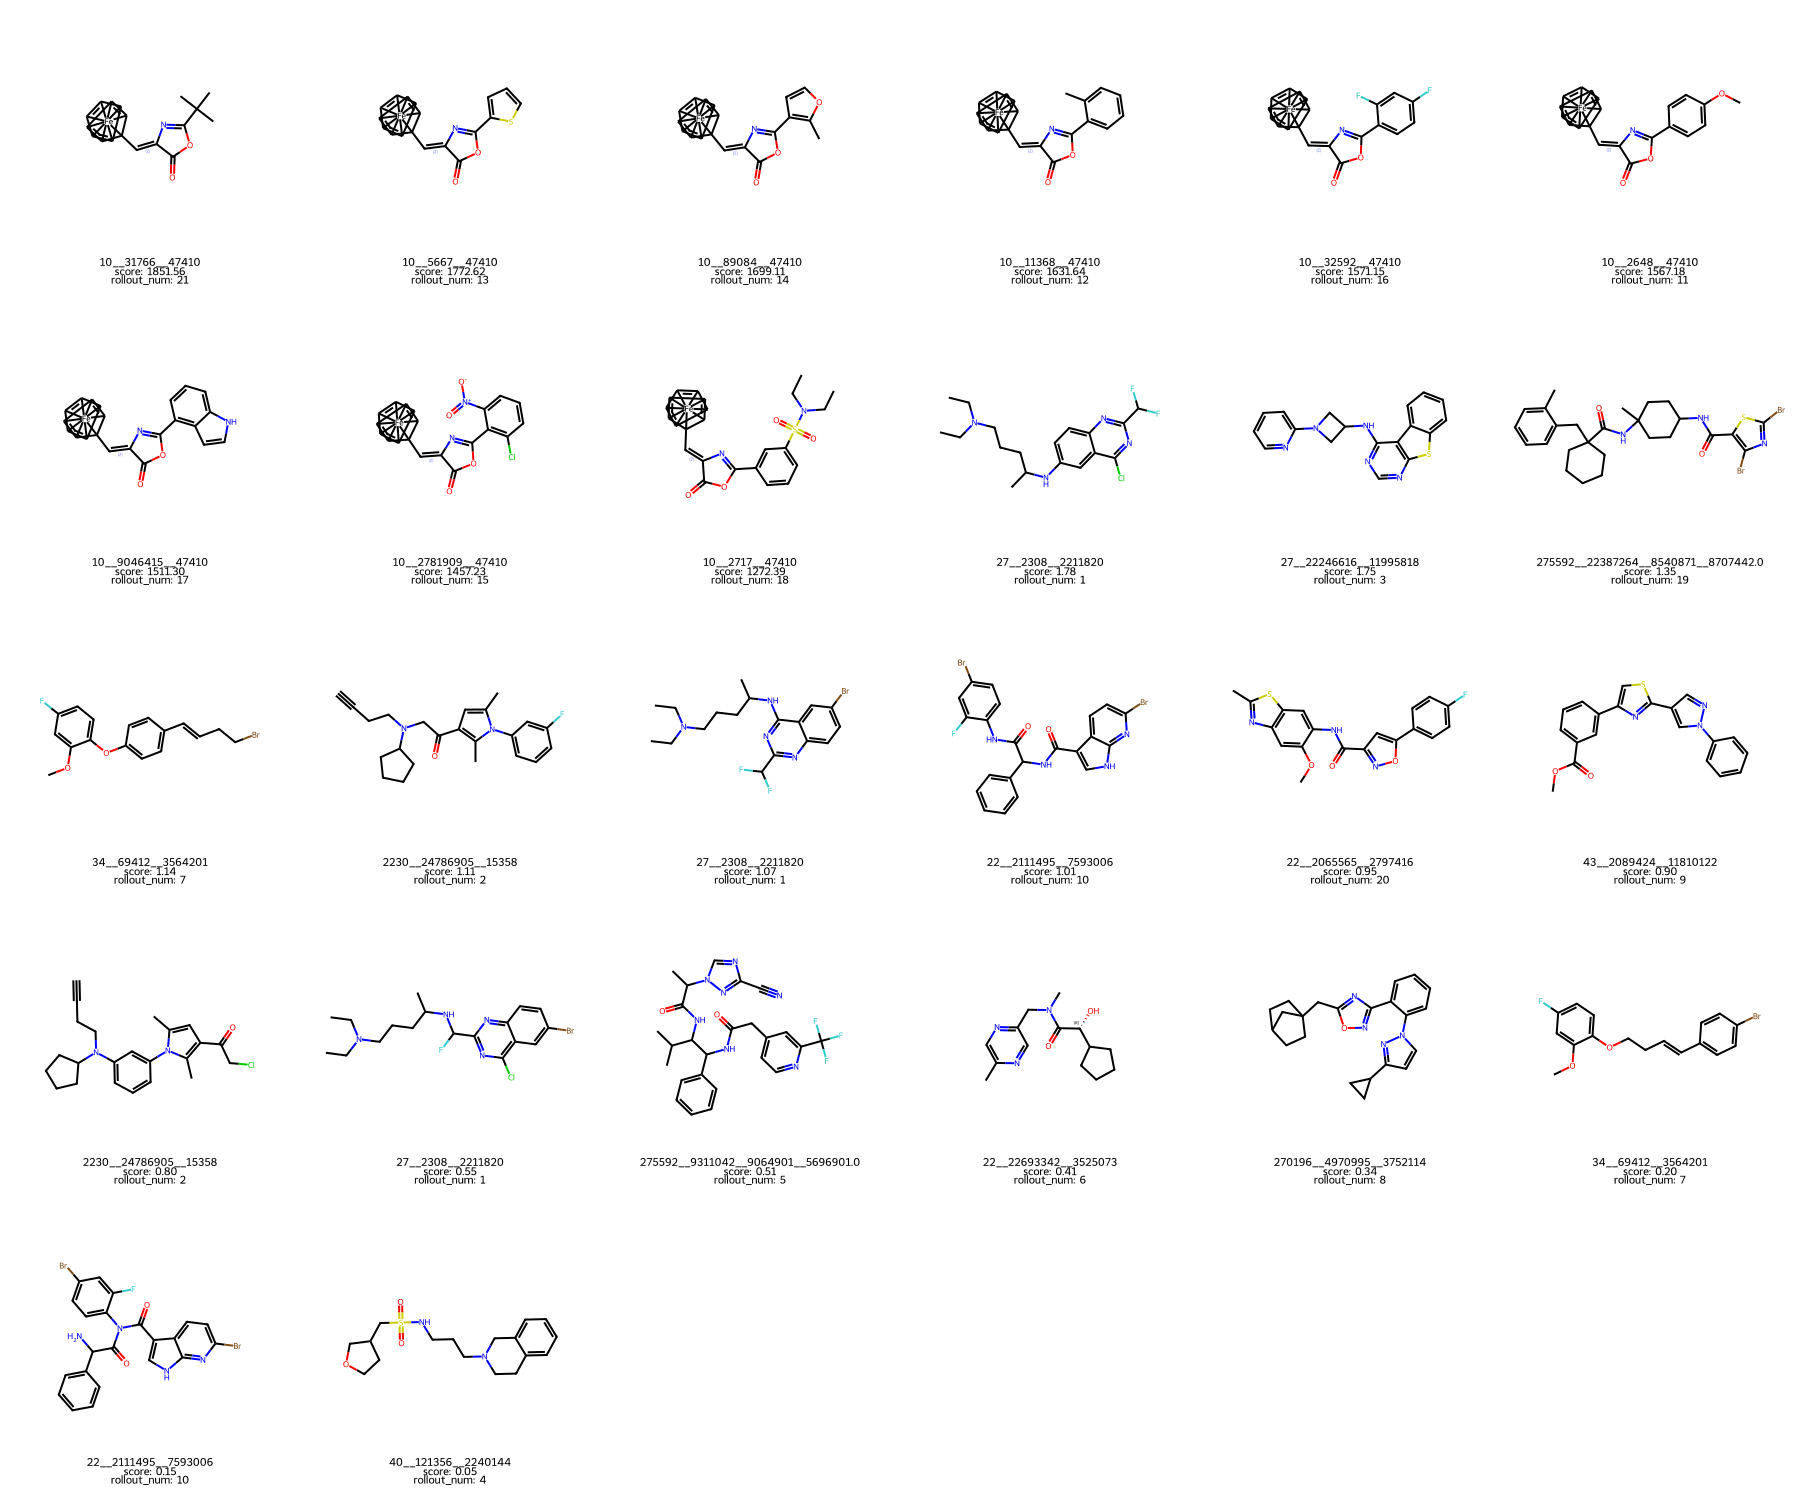

In [14]:

mols = [dm.to_mol(smiles) for smiles in mol_df[smiles_col]]

legend = [f"{fc}\nscore: {log2fc:.2f}\nrollout_num: {fdr:.0f}" for fc, log2fc, fdr in zip(mol_df['real_id'], mol_df['score'], mol_df['rollout_num'])]

dm.to_image(mols, legends=legend, n_cols = 6)